# Trial-by-Trial Neural Dynamics — BLA Protocol

Pipeline:
1. Load BLA epochs (subject 5, BLA channel group: T7, T8, TP7, TP8)
2. Baseline correction (−200 ms to 0 ms, mean subtraction)
3. ERP visualization per channel
4. Feature extraction per trial per channel:
   - Mean amplitude 0–100 ms
   - Mean amplitude 100–200 ms
   - Mean amplitude 200–400 ms
   - **Peak positive amplitude** in 0–300 ms (max µV in window)
   - **Peak latency** in 0–300 ms (time of that maximum, ms)
5. Trial-by-trial plots with rolling mean


In [26]:
#! pip install mne

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from pathlib import Path
from utils import load_eeg_data, CHANNEL_GROUPS

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## 1. Load Data

In [28]:
CONDITION  = "BLA"
SUBJECT_ID = 5
CHANNELS   = "BLA"   # T7, T8, TP7, TP8

# Data path (resolved inside utils): <project>/dataset/BLA/binepochs filtered ICArej BLAAvgBOS5.set
epochs = load_eeg_data(CONDITION, SUBJECT_ID, channels=CHANNELS)

data   = epochs.get_data()   # (n_trials, n_channels, n_times)  — in Volts (MNE default)
data   = data * 1e6           # convert to µV
times  = epochs.times        # in seconds
ch_names = epochs.ch_names
sfreq  = epochs.info['sfreq']

n_trials, n_channels, n_times = data.shape

print(f"Condition     : {CONDITION}  |  Subject: {SUBJECT_ID}")
print(f"Channels      : {ch_names}")
print(f"Trials        : {n_trials}")
print(f"Time window   : {times[0]*1000:.0f} ms  to  {times[-1]*1000:.0f} ms")
print(f"Sampling rate : {sfreq} Hz")
print(f"Data shape    : {data.shape}  (trials × channels × times)")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Condition     : BLA  |  Subject: 5
Channels      : ['T7', 'T8', 'TP7', 'TP8']
Trials        : 60
Time window   : -500 ms  to  2998 ms
Sampling rate : 512.0 Hz
Data shape    : (60, 4, 1792)  (trials × channels × times)


/Users/krabstse/Desktop/GT/课程/Physics of Cognition/Project/utils.py:130: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


## 2. Baseline Correction  (−200 ms to 0 ms, mean subtraction)

In [29]:
BASELINE_TMIN = -0.200   # seconds
BASELINE_TMAX =  0.000

baseline_mask = (times >= BASELINE_TMIN) & (times <= BASELINE_TMAX)
print(f"Baseline samples : {baseline_mask.sum()}  "
      f"({times[baseline_mask][0]*1000:.0f} ms to {times[baseline_mask][-1]*1000:.0f} ms)")

# Mean per trial × channel over the baseline window
baseline_mean = data[:, :, baseline_mask].mean(axis=-1, keepdims=True)  # (trials, channels, 1)

# Subtract from every time point
data_bc = data - baseline_mean   # (trials, channels, times)

print("Baseline correction done — data_bc shape:", data_bc.shape)

Baseline samples : 103  (-199 ms to 0 ms)
Baseline correction done — data_bc shape: (60, 4, 1792)


## 3. ERP Visualization per Channel

Average across all trials to reveal the event-related potential.

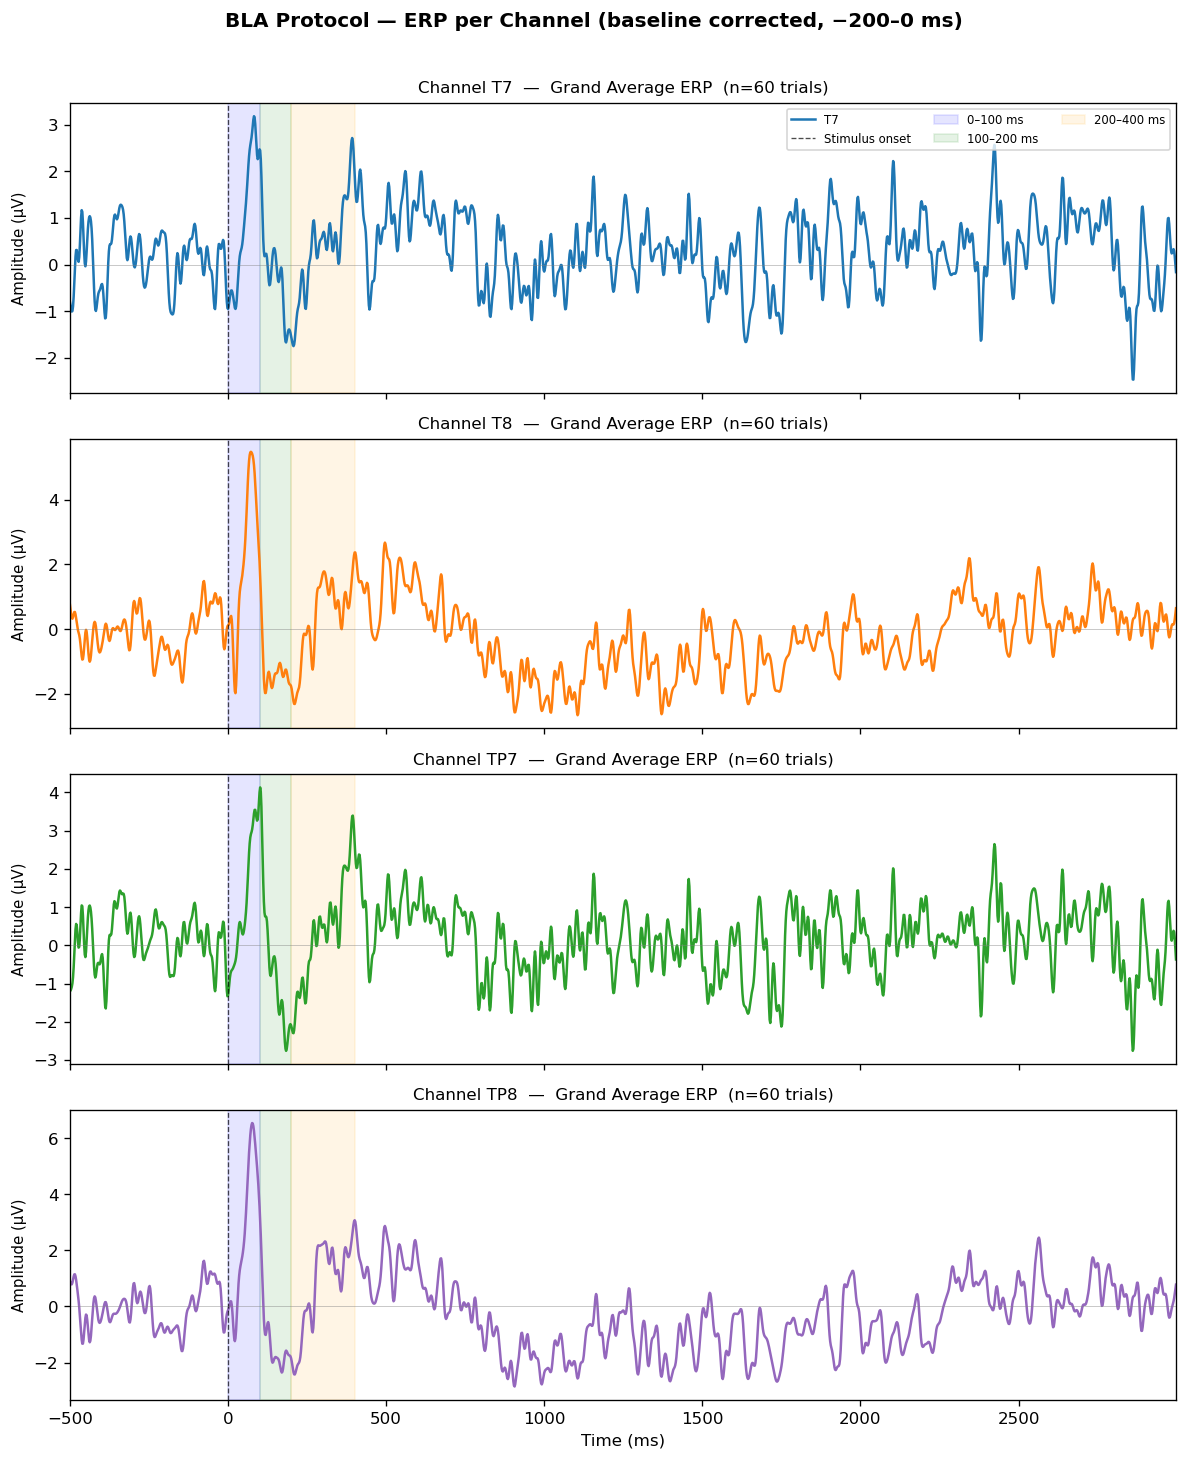

Figure saved: erp_BLA_per_channel.png


In [30]:
erp = data_bc.mean(axis=0)   # (n_channels, n_times)  — grand average ERP
times_ms = times * 1000      # convert to ms for plotting

fig, axes = plt.subplots(n_channels, 1, figsize=(10, 3 * n_channels), sharex=True)
if n_channels == 1:
    axes = [axes]

colors = plt.cm.tab10(np.linspace(0, 0.4, n_channels))

for i, (ax, ch) in enumerate(zip(axes, ch_names)):
    ax.plot(times_ms, erp[i], color=colors[i], linewidth=1.5, label=ch)
    ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.7, label='Stimulus onset')
    ax.axhline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

    # Shade feature windows
    ax.axvspan(0, 100,   alpha=0.10, color='blue',   label='0–100 ms')
    ax.axvspan(100, 200, alpha=0.10, color='green',  label='100–200 ms')
    ax.axvspan(200, 400, alpha=0.10, color='orange', label='200–400 ms')

    ax.set_ylabel('Amplitude (µV)', fontsize=9)
    ax.set_title(f'Channel {ch}  —  Grand Average ERP  (n={n_trials} trials)', fontsize=10)
    ax.set_xlim(times_ms[0], times_ms[-1])

    if i == 0:
        ax.legend(loc='upper right', fontsize=7, ncol=3)

axes[-1].set_xlabel('Time (ms)', fontsize=10)
fig.suptitle(f'BLA Protocol — ERP per Channel (baseline corrected, −200–0 ms)',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('erp_BLA_per_channel.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: erp_BLA_per_channel.png")

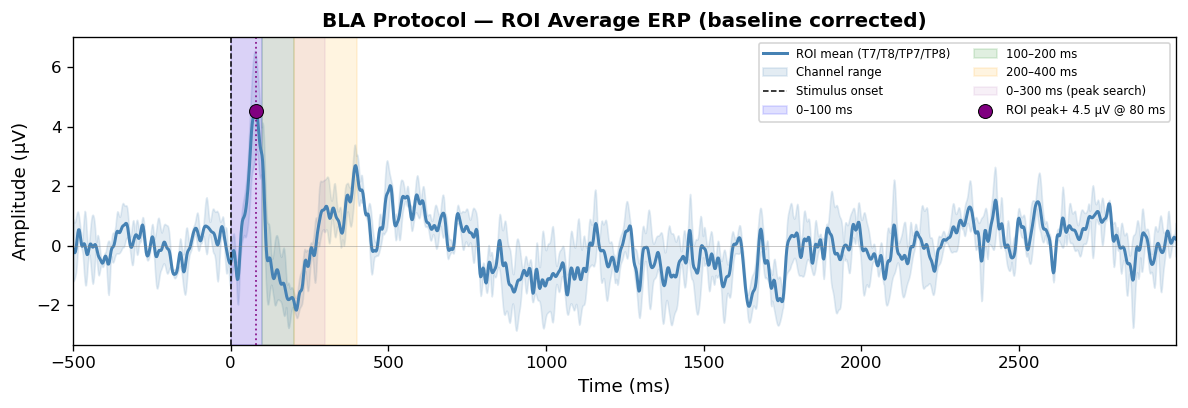

In [31]:
# --- ROI average ERP (mean across all BLA channels) ---
erp_roi = erp.mean(axis=0)   # (n_times,)

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(times_ms, erp_roi, color='steelblue', linewidth=1.8, label='ROI mean (T7/T8/TP7/TP8)')
ax.fill_between(times_ms, erp.min(axis=0), erp.max(axis=0),
                color='steelblue', alpha=0.15, label='Channel range')
ax.axvline(0, color='k', linestyle='--', linewidth=0.9, label='Stimulus onset')
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvspan(0, 100,   alpha=0.12, color='blue',   label='0–100 ms')
ax.axvspan(100, 200, alpha=0.12, color='green',  label='100–200 ms')
ax.axvspan(200, 400, alpha=0.12, color='orange', label='200–400 ms')
ax.axvspan(0, 300, alpha=0.06, color='purple', label='0–300 ms (peak search)')

# Grand-average ROI: peak positive & latency in 0–300 ms (same definition as trial features)
_pk_mask = (times_ms >= 0) & (times_ms <= 300)
_t = times_ms[_pk_mask]
_v = erp_roi[_pk_mask]
_i = int(np.argmax(_v))
_lat, _amp = _t[_i], _v[_i]
ax.scatter([_lat], [_amp], color='purple', s=70, zorder=6, edgecolors='k', linewidths=0.6,
           label=f'ROI peak+ {_amp:.1f} µV @ {_lat:.0f} ms')
ax.axvline(_lat, color='purple', linestyle=':', linewidth=1.1, alpha=0.85)

ax.set_xlabel('Time (ms)', fontsize=11)
ax.set_ylabel('Amplitude (µV)', fontsize=11)
ax.set_title('BLA Protocol — ROI Average ERP (baseline corrected)', fontsize=12, fontweight='bold')
ax.set_xlim(times_ms[0], times_ms[-1])
ax.legend(loc='upper right', fontsize=7, ncol=2)
fig.tight_layout()
plt.savefig('erp_BLA_roi_average.png', bbox_inches='tight', dpi=150)
plt.show()


## 4. Feature Extraction per Trial × Channel

For each trial and each channel we compute:

**Mean amplitude** (baseline-corrected) in three post-stimulus windows:
- **0–100 ms** (early sensory)
- **100–200 ms** (N1/P2 range)
- **200–400 ms** (later processing)

**Peak metrics in 0–300 ms:**
- **Peak positive amplitude**: maximum baseline-corrected voltage in that window (µV) — local positive peak.
- **Peak latency**: time of that maximum relative to stimulus onset (ms).


In [32]:
# Time masks for each feature window
mask_0_100   = (times >= 0.000) & (times <= 0.100)
mask_100_200 = (times >= 0.100) & (times <= 0.200)
mask_200_400 = (times >= 0.200) & (times <= 0.400)
mask_0_300   = (times >= 0.000) & (times <= 0.300)   # peak search window

print("Window sample counts:")
print(f"  0–100 ms  : {mask_0_100.sum()} samples")
print(f"  100–200 ms: {mask_100_200.sum()} samples")
print(f"  200–400 ms: {mask_200_400.sum()} samples")
print(f"  0–300 ms  : {mask_0_300.sum()} samples (peak amp / latency)")

# Feature arrays: (n_trials, n_channels) — mean amplitude windows
feat_0_100   = data_bc[:, :, mask_0_100].mean(axis=-1)
feat_100_200 = data_bc[:, :, mask_100_200].mean(axis=-1)
feat_200_400 = data_bc[:, :, mask_200_400].mean(axis=-1)

# Peak positive amplitude & latency in 0–300 ms (per trial × channel)
times_0_300 = times[mask_0_300]
win_0_300 = data_bc[:, :, mask_0_300]   # (trials, ch, samples)
peak_ix = win_0_300.argmax(axis=-1)   # index of maximum µV in window
feat_peak_amp_0_300 = np.take_along_axis(win_0_300, peak_ix[..., None], axis=-1).squeeze(-1)
feat_peak_lat_0_300_ms = times_0_300[peak_ix] * 1000.0   # seconds → ms

# ROI average across channels: (n_trials,)
roi_0_100   = feat_0_100.mean(axis=1)
roi_100_200 = feat_100_200.mean(axis=1)
roi_200_400 = feat_200_400.mean(axis=1)
roi_peak_amp_0_300 = feat_peak_amp_0_300.mean(axis=1)
roi_peak_lat_0_300 = feat_peak_lat_0_300_ms.mean(axis=1)

trial_idx = np.arange(1, n_trials + 1)

# Collect into a DataFrame for easy inspection
rows = []
for t in range(n_trials):
    for c, ch in enumerate(ch_names):
        rows.append({
            'trial': t + 1,
            'channel': ch,
            'amp_0_100':   feat_0_100[t, c],
            'amp_100_200': feat_100_200[t, c],
            'amp_200_400': feat_200_400[t, c],
            'peak_pos_amp_0_300_uv': feat_peak_amp_0_300[t, c],
            'peak_lat_0_300_ms':     feat_peak_lat_0_300_ms[t, c],
        })
features_df = pd.DataFrame(rows)
print("\nFeature DataFrame (first 8 rows):")
features_df.head(8)


Window sample counts:
  0–100 ms  : 52 samples
  100–200 ms: 51 samples
  200–400 ms: 102 samples
  0–300 ms  : 154 samples (peak amp / latency)

Feature DataFrame (first 8 rows):


,trial,channel,amp_0_100,amp_100_200,amp_200_400,peak_pos_amp_0_300_uv,peak_lat_0_300_ms
0,1,T7,5.609618,4.393832,-0.608417,19.245318,101.562500
1,1,T8,2.234826,0.482644,-0.955328,14.463423,246.093750
2,1,TP7,5.822789,5.543579,-0.544146,26.753023,101.562500
3,1,TP8,2.812455,0.908756,-1.692234,14.704839,246.093750
4,2,T7,-2.123390,-4.686120,-7.726102,3.780155,41.015625
5,2,T8,1.773534,1.665672,-6.738448,13.890123,175.781250
6,2,TP7,-1.716981,-4.199324,-8.407957,6.726034,97.656250
7,2,TP8,3.734365,4.085105,-7.245894,14.177499,177.734375


In [33]:
# Basic statistics across trials (ROI average)
print("ROI-averaged feature statistics across trials:")
summary = pd.DataFrame({
    '0–100 ms':   roi_0_100,
    '100–200 ms': roi_100_200,
    '200–400 ms': roi_200_400,
    'Peak+ 0–300 µV': roi_peak_amp_0_300,
    'Peak lat 0–300 ms': roi_peak_lat_0_300,
})
summary.describe().round(4)


ROI-averaged feature statistics across trials:


,0–100 ms,100–200 ms,200–400 ms,Peak+ 0–300 µV,Peak lat 0–300 ms
count,60.0000,60.0000,60.0000,60.0000,60.0000
mean,1.7242,-0.8289,0.4251,12.2372,118.4977
std,3.0183,3.6011,3.6763,3.9271,59.1244
min,-4.8231,-8.1690,-7.6020,4.4974,11.7188
25%,0.3527,-2.5712,-2.0540,9.0962,75.5615
50%,1.8257,-0.9880,0.3722,11.5942,104.7363
75%,3.5422,2.3458,2.7674,14.7568,168.9453
max,8.1716,6.7035,9.6227,22.8294,259.7656


## 5. Trial-by-Trial Dynamics

Plot each feature against trial index and overlay a rolling mean to reveal learning-related trends.

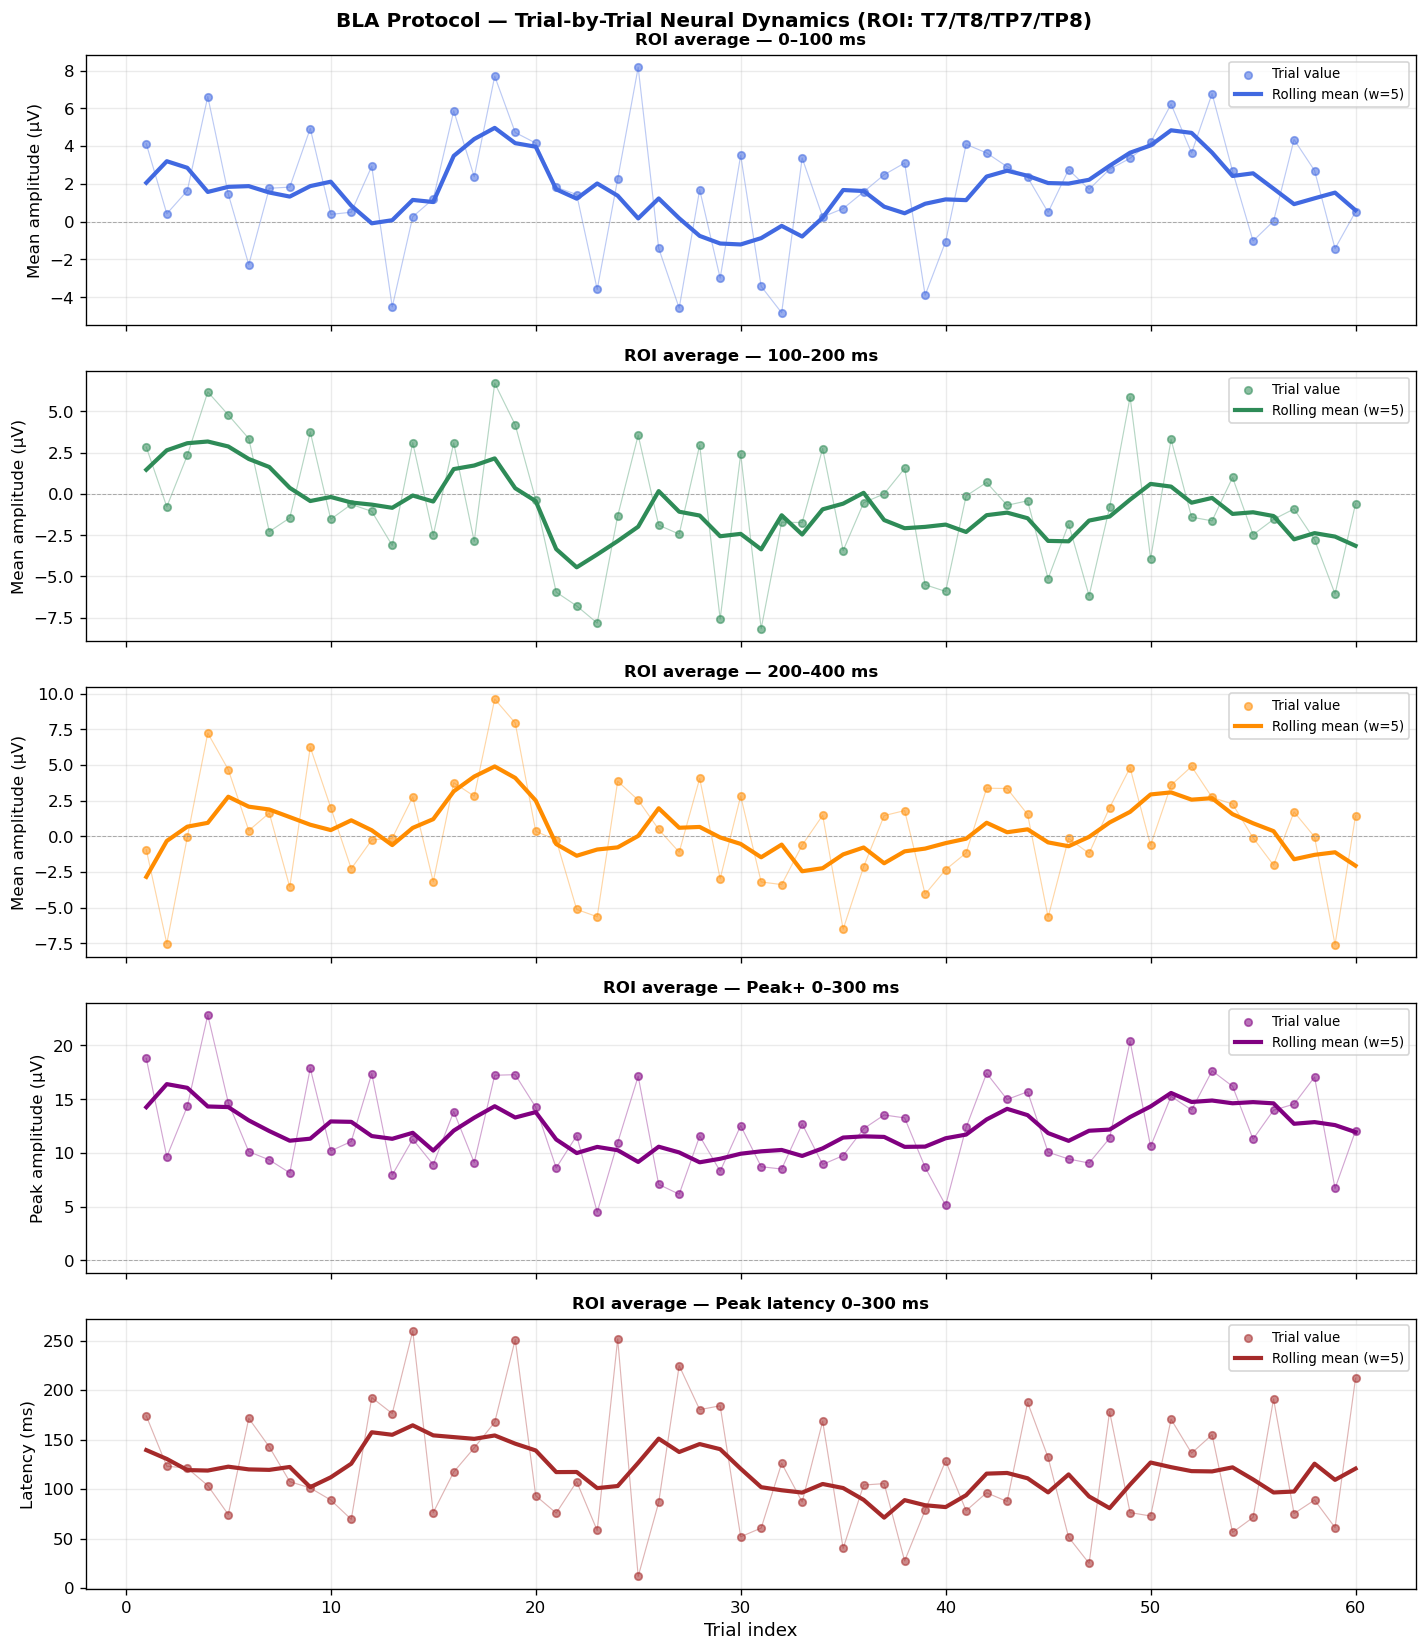

Figure saved: trial_dynamics_BLA_roi.png


In [34]:
ROLLING_WINDOW = 5   # trials in the moving average

windows = [
    ('0–100 ms',   roi_0_100,   'royalblue',   'Mean amplitude (µV)'),
    ('100–200 ms', roi_100_200, 'seagreen',    'Mean amplitude (µV)'),
    ('200–400 ms', roi_200_400, 'darkorange',  'Mean amplitude (µV)'),
    ('Peak+ 0–300 ms', roi_peak_amp_0_300, 'purple', 'Peak amplitude (µV)'),
    ('Peak latency 0–300 ms', roi_peak_lat_0_300, 'brown', 'Latency (ms)'),
]

fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

for ax, (label, values, color, ylab) in zip(axes, windows):
    ax.scatter(trial_idx, values, color=color, s=20, alpha=0.55, zorder=2, label='Trial value')
    ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.35, zorder=1)

    s = pd.Series(values)
    rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
    ax.plot(trial_idx, rolling, color=color, linewidth=2.5, zorder=3,
            label=f'Rolling mean (w={ROLLING_WINDOW})')

    if not label.startswith('Peak latency'):
        ax.axhline(0, color='gray', linewidth=0.6, linestyle='--', alpha=0.6)
    ax.set_ylabel(ylab, fontsize=10)
    ax.set_title(f'ROI average — {label}', fontsize=10, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Trial index', fontsize=11)
fig.suptitle(f'BLA Protocol — Trial-by-Trial Neural Dynamics (ROI: T7/T8/TP7/TP8)',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('trial_dynamics_BLA_roi.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: trial_dynamics_BLA_roi.png")


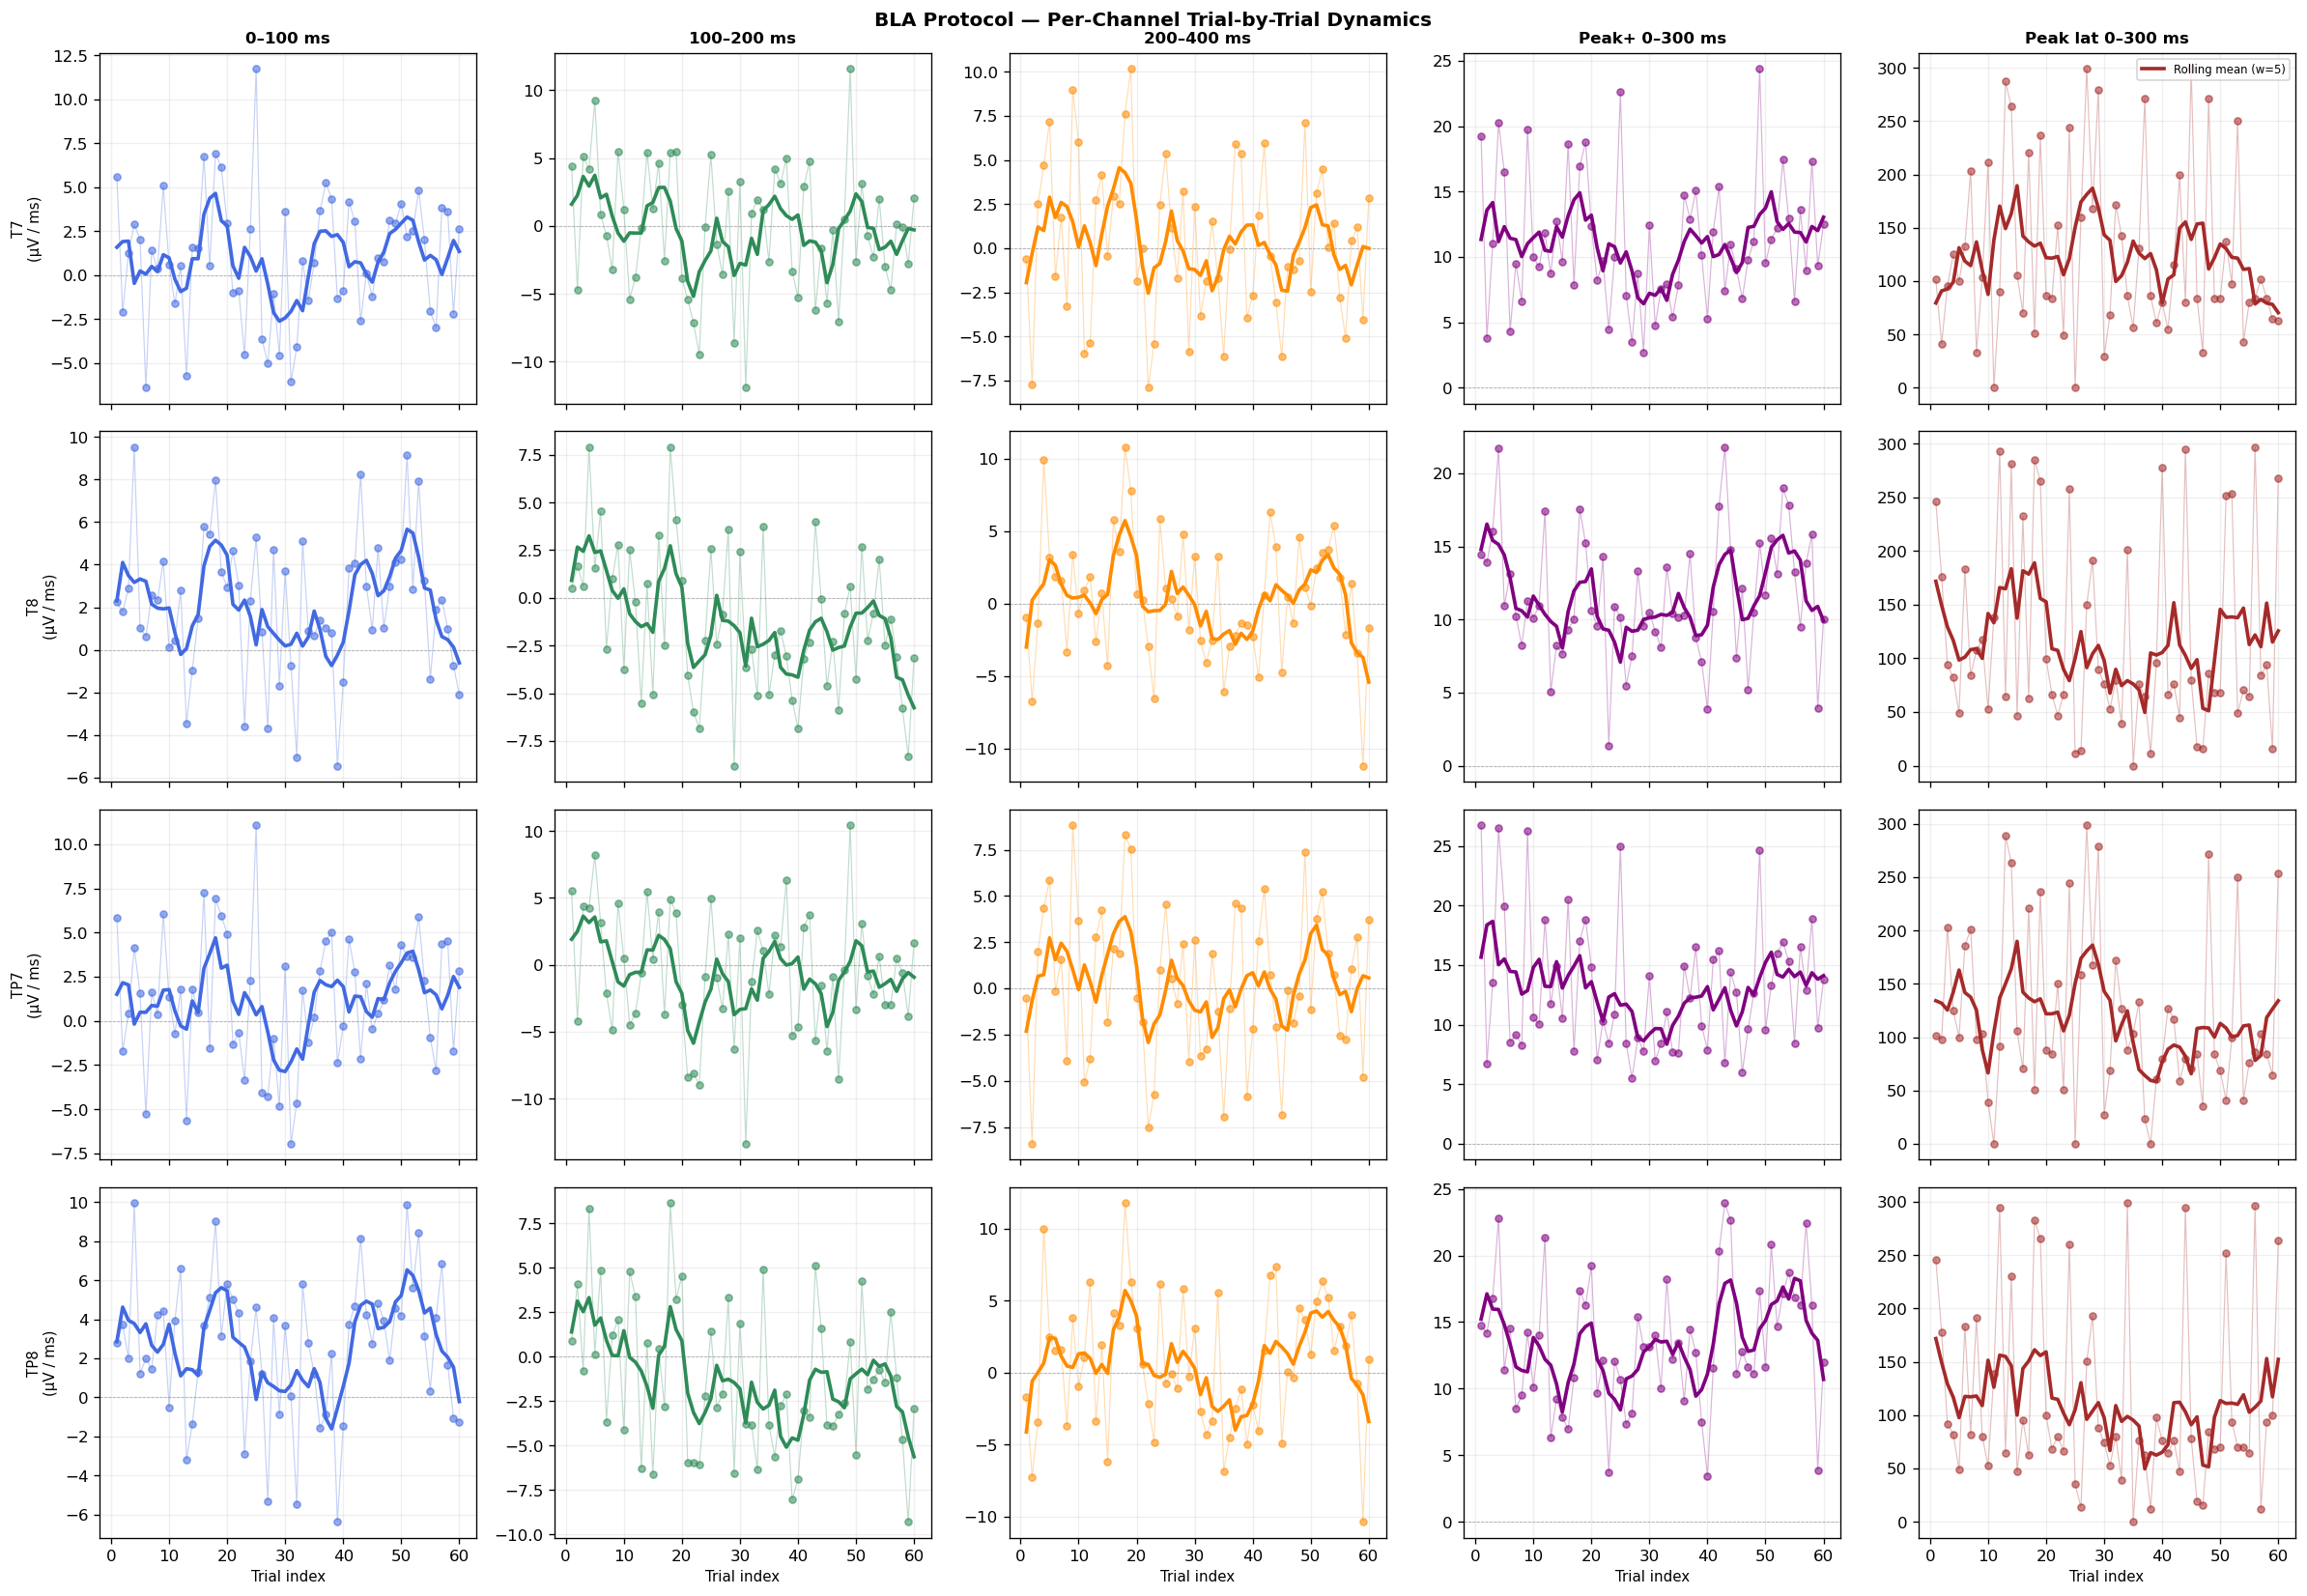

Figure saved: trial_dynamics_BLA_per_channel.png


In [35]:
# --- Per-channel trial-by-trial dynamics ---

feat_arrays = [
    ('0–100 ms',   feat_0_100,   'royalblue'),
    ('100–200 ms', feat_100_200, 'seagreen'),
    ('200–400 ms', feat_200_400, 'darkorange'),
    ('Peak+ 0–300 ms', feat_peak_amp_0_300, 'purple'),
    ('Peak lat 0–300 ms', feat_peak_lat_0_300_ms, 'brown'),
]

fig, axes = plt.subplots(n_channels, 5,
                          figsize=(20, 3.5 * n_channels),
                          sharex=True)

if n_channels == 1:
    axes = axes[np.newaxis, :]

for row, ch in enumerate(ch_names):
    for col, (label, feat_arr, color) in enumerate(feat_arrays):
        ax = axes[row, col]
        values = feat_arr[:, row]

        ax.scatter(trial_idx, values, color=color, s=18, alpha=0.55, zorder=2)
        ax.plot(trial_idx, values, color=color, linewidth=0.7, alpha=0.30, zorder=1)

        s = pd.Series(values)
        rolling = s.rolling(window=ROLLING_WINDOW, center=True, min_periods=1).mean()
        ax.plot(trial_idx, rolling, color=color, linewidth=2.2, zorder=3,
                label=f'Rolling mean (w={ROLLING_WINDOW})')

        if col != 4:
            ax.axhline(0, color='gray', linewidth=0.5, linestyle='--', alpha=0.6)
        ax.grid(True, alpha=0.2)

        if row == 0:
            ax.set_title(label, fontsize=10, fontweight='bold')
        if col == 0:
            ax.set_ylabel(f'{ch}\n(µV / ms)', fontsize=9)
        if row == n_channels - 1:
            ax.set_xlabel('Trial index', fontsize=9)

        if row == 0 and col == 4:
            ax.legend(fontsize=7, loc='upper right')

fig.suptitle('BLA Protocol — Per-Channel Trial-by-Trial Dynamics',
             fontsize=12, fontweight='bold')
fig.tight_layout()
plt.savefig('trial_dynamics_BLA_per_channel.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved: trial_dynamics_BLA_per_channel.png")


## Summary

| Step | Details |
|---|---|
| Protocol | BLA (Baseline Audio) |
| Subject | 5 |
| ROI | T7, T8, TP7, TP8 (temporal/temporo-parietal) |
| Trials (auditory) | varies ("No auditory" removed by `load_eeg_data`) |
| Baseline window | −200 ms to 0 ms, mean subtraction |
| Feature windows | 0–100, 100–200, 200–400 ms (mean µV); 0–300 ms (peak µV + peak latency ms) |
| Rolling mean window | 5 trials (centered) |

Next steps:
- Repeat for other protocols (BLT, P1, P2, P3)
- Compare learning curves across protocols
- Statistical tests (e.g., linear regression of feature ~ trial_index)
